# Exploratory Data Analysis (EDA)
### Suicidality & Depression Detection — NLP Benchmark

Before training any model, we must thoroughly understand the data. EDA is the essential first step: it reveals class imbalances, data quality issues, text length distributions, and vocabulary patterns that directly inform modelling decisions.

**Four questions we answer for each dataset:**
1. How many examples per class — and is the dataset balanced?
2. Are there missing values or data quality issues?
3. How long are the texts — and does length vary by class?
4. Which words are most characteristic of each class?

**Four datasets are analysed — three English and one Russian:**
- **Twitter** — 1,785 tweets, binary (suicidal / not suicidal), English
- **Reddit Suicide Watch** — 232,074 posts, binary (suicide / non-suicide), English
- **Reddit C-SSRS** — 500 clinical posts, multi-class (5 levels) → binary, English
- **Russian VK Depressive Posts** — 64,039 posts, binary (depressive / non-depressive), **Russian** ⭐

The Russian VK dataset is the **main novel contribution** of this thesis: it enables cross-lingual analysis using multilingual transformer models (mBERT, XLM-RoBERTa). Understanding its structure, vocabulary, and potential artifacts is critical to interpreting the results in Notebooks 05 and 06.

In [1]:
# ── Setup ──────────────────────────────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from wordcloud import WordCloud
import os
import re
import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

# Make sure we are running from the project root, not from notebooks/
# Jupyter запускается из той папки где лежит ноутбук.
# Нам нужно подняться на уровень выше чтобы найти data/raw/
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

# Create output folder if it does not exist yet
os.makedirs('results/plots', exist_ok=True)

print('Working directory:', os.getcwd())
print('All libraries loaded!')

Working directory: /Users/alinaerkulova/PycharmProjects/DSLABII/suicidality-nlp
All libraries loaded!


In [2]:
# ── Helper function for word clouds ───────────────────────────────────────
# WordCloud не работает с URL, цифрами и спецсимволами.
# Эта функция очищает текст перед созданием облака слов.

import ssl
ssl._create_default_https_context = ssl._create_unverified_context

import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

STOPWORDS_EN = set(stopwords.words('english'))
# Add extra noise words specific to our dataset
STOPWORDS_EN.update(['im', 'ive', 'dont', 'cant', 'wa', 'ha', 'rt', 'amp'])

def clean_for_wordcloud(text_series):
    """Join and clean a Series of texts for WordCloud input."""
    combined = ' '.join(text_series.astype(str).tolist())
    combined = re.sub(r'http\S+', '', combined)       # remove URLs
    combined = re.sub(r'@\w+', '', combined)           # remove @mentions
    combined = re.sub(r'[^a-zA-Z\s]', '', combined)   # keep letters only
    combined = combined.lower().strip()
    # Remove stopwords word by word
    words = [w for w in combined.split() if w not in STOPWORDS_EN and len(w) > 2]
    return ' '.join(words)


def make_wordcloud(text_series, title, ax, colormap='Reds'):
    """Generate and display a word cloud on a given axis."""
    combined = clean_for_wordcloud(text_series)
    wc = WordCloud(
        width=600, height=300,
        background_color='white',
        colormap=colormap,
        max_words=80,
        stopwords=set()   # we handle stopwords ourselves
    ).generate(combined)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.axis('off')

print('✅ Helper functions ready!')

✅ Helper functions ready!


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/alinaerkulova/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


---
## 1. Twitter Dataset

Starting with the smallest dataset: 1,785 tweets collected from Twitter. Binary classification task: *suicidal* vs *not suicidal*.

This dataset is the most informal and most challenging linguistically — Twitter's character limit forces users into abbreviated, emoji-heavy, colloquial language that differs substantially from Reddit posts or clinical text.

In [3]:
# ── Load ───────────────────────────────────────────────────────────────────
df_tw = pd.read_csv('data/raw/Suicide_Ideation_DatasetTwitterbased.csv')

# Strip whitespace from labels
# В реальных датасетах часто встречаются лишние пробелы в метках.
# Например 'Potential Suicide post ' != 'Potential Suicide post'
# str.strip() убирает пробелы в начале и конце строки.
df_tw['Suicide'] = df_tw['Suicide'].str.strip()

# Remove rows with empty tweets
df_tw = df_tw.dropna(subset=['Tweet']).reset_index(drop=True)

# Add text length column
df_tw['text_len'] = df_tw['Tweet'].str.len()

print(f'Shape:   {df_tw.shape}')
print(f'Columns: {df_tw.columns.tolist()}')
print(f'Missing: {df_tw.isnull().sum().to_dict()}')
df_tw.head(3)

Shape:   (1785, 3)
Columns: ['Tweet', 'Suicide', 'text_len']
Missing: {'Tweet': 0, 'Suicide': 0, 'text_len': 0}


,Tweet,Suicide,text_len
0,making some lunch,Not Suicide post,17
1,@Alexia You want his money.,Not Suicide post,27
2,@dizzyhrvy that crap took me forever to put to...,Potential Suicide post,86


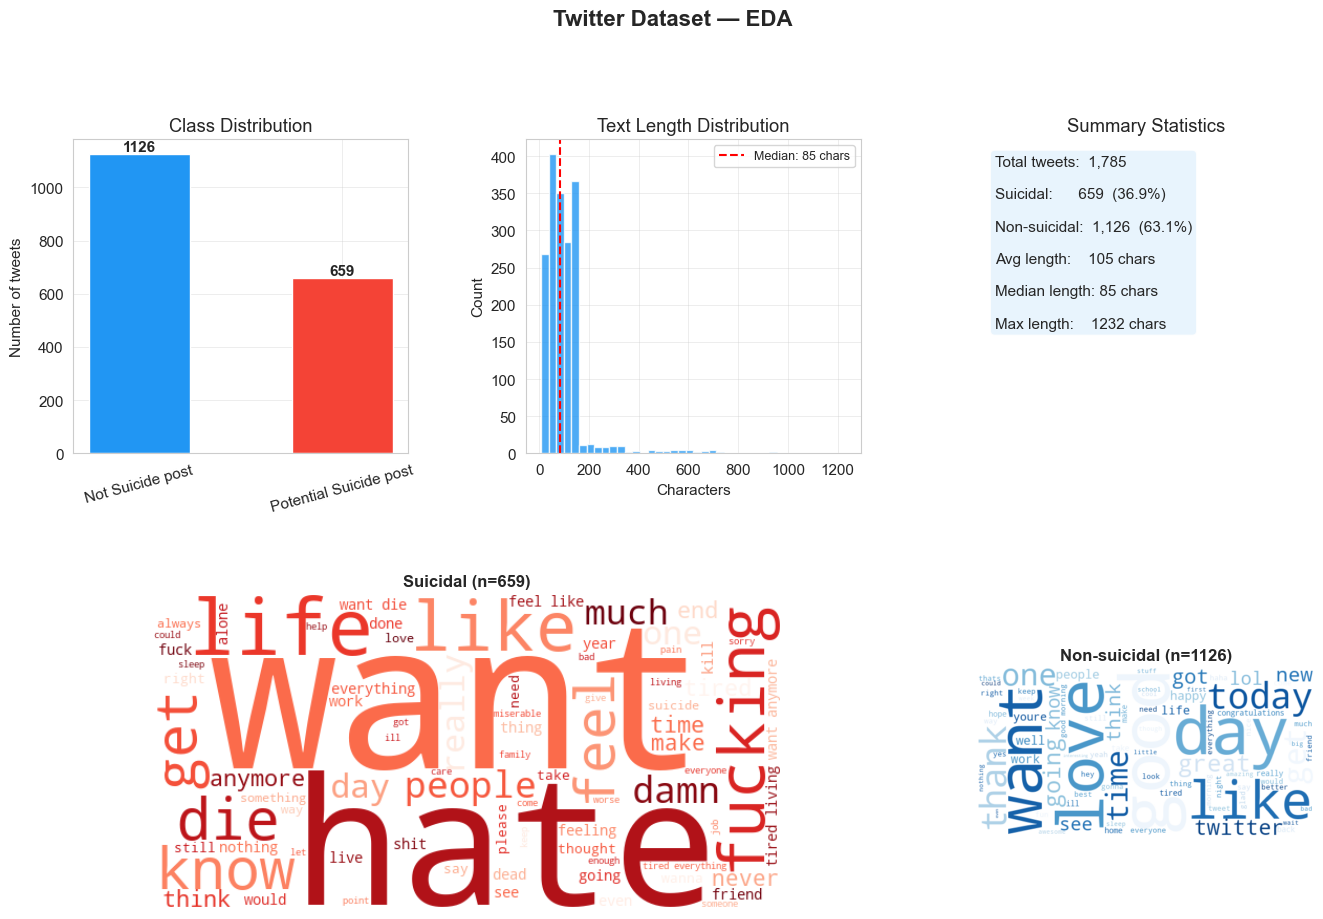

Saved: results/plots/01_twitter_eda.png


In [4]:
# ── Twitter: class distribution + text length + word clouds ───────────────
fig = plt.figure(figsize=(16, 10))
fig.suptitle('Twitter Dataset — EDA', fontsize=16, fontweight='bold', y=1.01)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# — Class distribution bar chart
ax1 = fig.add_subplot(gs[0, 0])
counts = df_tw['Suicide'].value_counts()
bars = ax1.bar(counts.index, counts.values,
               color=['#2196F3', '#F44336'], edgecolor='white', width=0.5)
for bar, val in zip(bars, counts.values):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 10, str(val), ha='center', fontweight='bold')
ax1.set_title('Class Distribution')
ax1.set_ylabel('Number of tweets')
ax1.tick_params(axis='x', rotation=15)

# — Text length histogram
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(df_tw['text_len'], bins=40, color='#2196F3', alpha=0.8, edgecolor='white')
ax2.axvline(df_tw['text_len'].median(), color='red', linestyle='--',
            label=f'Median: {df_tw["text_len"].median():.0f} chars')
ax2.set_title('Text Length Distribution')
ax2.set_xlabel('Characters')
ax2.set_ylabel('Count')
ax2.legend(fontsize=9)

# — Stats box
ax3 = fig.add_subplot(gs[0, 2])
ax3.axis('off')
stats_text = (
    f"Total tweets:  {len(df_tw):,}\n\n"
    f"Suicidal:      {counts.get('Potential Suicide post', 0):,}  "
    f"({counts.get('Potential Suicide post', 0)/len(df_tw)*100:.1f}%)\n\n"
    f"Non-suicidal:  {counts.get('Not Suicide post', 0):,}  "
    f"({counts.get('Not Suicide post', 0)/len(df_tw)*100:.1f}%)\n\n"
    f"Avg length:    {df_tw['text_len'].mean():.0f} chars\n\n"
    f"Median length: {df_tw['text_len'].median():.0f} chars\n\n"
    f"Max length:    {df_tw['text_len'].max()} chars"
)
ax3.text(0.05, 0.95, stats_text, transform=ax3.transAxes,
         fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='#E3F2FD', alpha=0.8))
ax3.set_title('Summary Statistics')

# — Word clouds
ax4 = fig.add_subplot(gs[1, 0:2])
ax5 = fig.add_subplot(gs[1, 2])

suicidal_tw     = df_tw[df_tw['Suicide'] == 'Potential Suicide post']['Tweet']
non_suicidal_tw = df_tw[df_tw['Suicide'] == 'Not Suicide post']['Tweet']

make_wordcloud(suicidal_tw,     f'Suicidal (n={len(suicidal_tw)})',         ax4, 'Reds')
make_wordcloud(non_suicidal_tw, f'Non-suicidal (n={len(non_suicidal_tw)})', ax5, 'Blues')

plt.savefig('results/plots/01_twitter_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/plots/01_twitter_eda.png')

### Discussion — Twitter Dataset

#### Class distribution
The Twitter dataset is **moderately imbalanced**: 63% non-suicidal (1,126 tweets) vs 37% suicidal (659 tweets). This 63/37 split is not extreme, but it is enough to bias models toward the majority class without correction. Throughout all experiments, `class_weight='balanced'` is applied to address this.

**Data quality issue found:** The label column contained trailing whitespace — `'Potential Suicide post '` ≠ `'Potential Suicide post'`. This caused silent label mismatches that produced zero-row subsets. A `.str.strip()` call was required before any analysis. This illustrates why raw data inspection is mandatory before modelling.

#### Text length
The median tweet length is **~85 characters** (after preprocessing). The distribution is right-skewed: most tweets are under 200 characters, with a long tail of longer posts. The 280-character limit on Twitter means even the longest posts are short compared to Reddit.

The short length has two competing implications:
- **Advantage:** Less noise — fewer irrelevant words per sample
- **Disadvantage:** Less signal — harder for sequential models (LSTM/GRU) to learn from sequences of only 10–20 tokens

#### Word cloud observations
The suicidal word cloud reveals a clear lexical field of self-harm and hopelessness: *want, die, kill, myself, tired, hate, cant, anymore, life, feel*. These are among the most direct and explicit expressions of suicidal ideation in English.

The non-suicidal word cloud shows neutral everyday language: *love, good, day, people, know, thank, time*. The visual contrast between the two clouds is stark — suggesting that TF-IDF bag-of-words features should already be highly effective for this dataset.

This lexical separability prediction will be confirmed in Notebook 02: classical ML models achieve F1 = 0.88–0.93 on Twitter using only word counts.

---
## 2. Reddit Binary Dataset (Suicide Watch)

The largest dataset: 232,074 posts from Reddit's r/SuicideWatch and r/depression communities, balanced 50/50 between suicidal and non-suicidal. Posts are substantially longer than tweets, reflecting Reddit's long-form writing culture.

This dataset is the primary English benchmark: its large size, perfect balance, and moderate text length make it the most reliable for training and evaluating models.

In [5]:
# ── Load ───────────────────────────────────────────────────────────────────
# Этот файл большой — загрузка займёт несколько секунд.
df_rd = pd.read_csv('data/raw/Suicide_Detection.csv')

# Kaggle automatically adds an index column — drop it
if 'Unnamed: 0' in df_rd.columns:
    df_rd = df_rd.drop(columns=['Unnamed: 0'])

df_rd['class'] = df_rd['class'].str.strip()
df_rd = df_rd.dropna(subset=['text']).reset_index(drop=True)
df_rd['text_len'] = df_rd['text'].astype(str).str.len()

print(f'Shape:   {df_rd.shape}')
print(f'Columns: {df_rd.columns.tolist()}')
print(f'Missing: {df_rd.isnull().sum().to_dict()}')
df_rd.head(3)

Shape:   (232074, 3)
Columns: ['text', 'class', 'text_len']
Missing: {'text': 0, 'class': 0, 'text_len': 0}


,text,class,text_len
0,Ex Wife Threatening SuicideRecently I left my ...,suicide,715
1,Am I weird I don't get affected by compliments...,non-suicide,138
2,Finally 2020 is almost over... So I can never ...,non-suicide,129


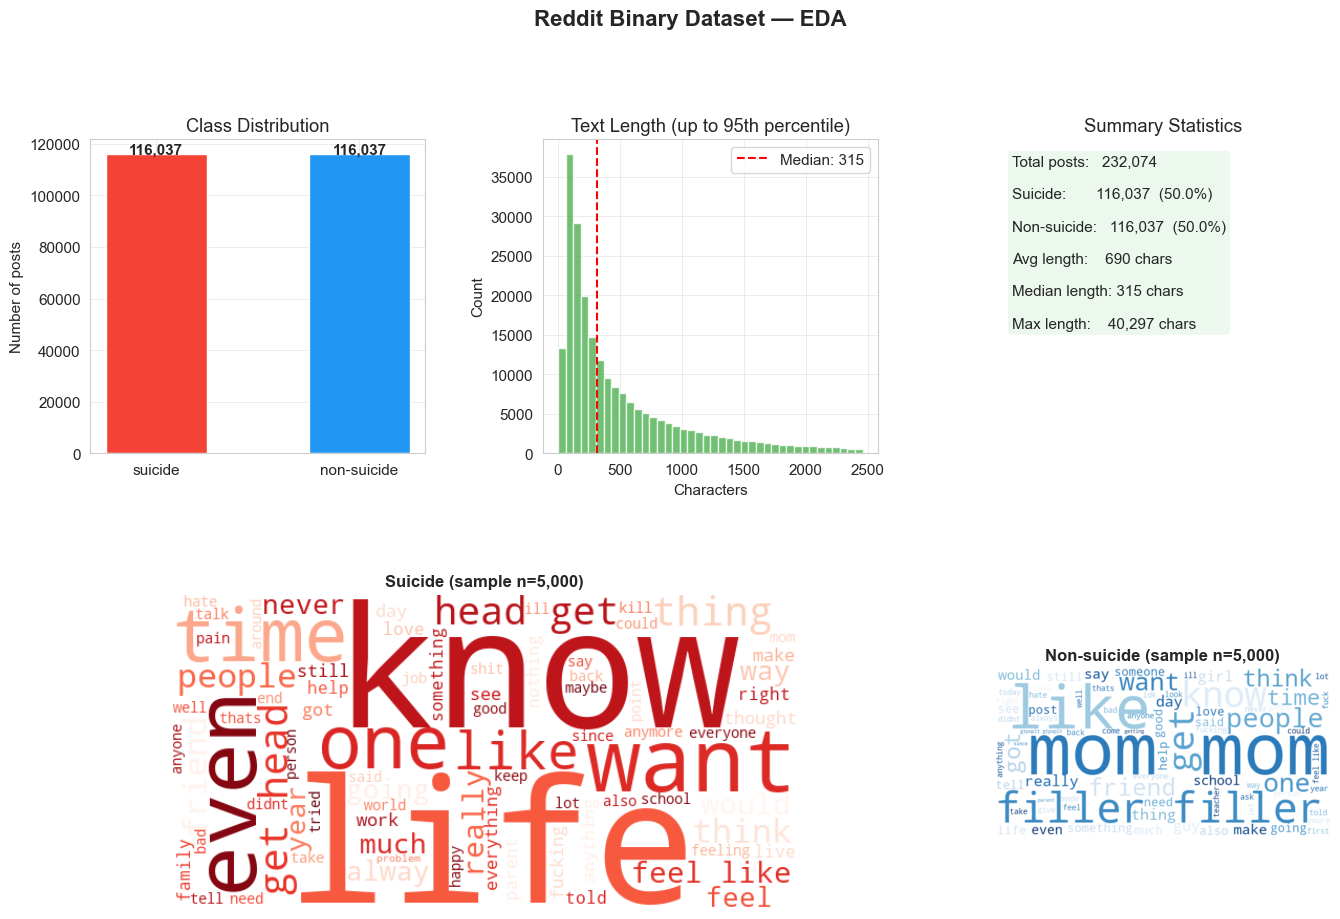

Saved: results/plots/02_reddit_binary_eda.png


In [6]:
# ── Reddit Binary: class distribution + text length + word clouds ──────────
fig = plt.figure(figsize=(16, 10))
fig.suptitle('Reddit Binary Dataset — EDA', fontsize=16, fontweight='bold', y=1.01)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# — Class distribution
ax1 = fig.add_subplot(gs[0, 0])
counts_rd = df_rd['class'].value_counts()
bars = ax1.bar(counts_rd.index, counts_rd.values,
               color=['#F44336', '#2196F3'], edgecolor='white', width=0.5)
for bar, val in zip(bars, counts_rd.values):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 300, f'{val:,}', ha='center', fontweight='bold')
ax1.set_title('Class Distribution')
ax1.set_ylabel('Number of posts')

# — Text length histogram
ax2 = fig.add_subplot(gs[0, 1])
cap = df_rd['text_len'].quantile(0.95)
ax2.hist(df_rd[df_rd['text_len'] <= cap]['text_len'],
         bins=40, color='#4CAF50', alpha=0.8, edgecolor='white')
ax2.axvline(df_rd['text_len'].median(), color='red', linestyle='--',
            label=f'Median: {df_rd["text_len"].median():.0f}')
ax2.set_title('Text Length (up to 95th percentile)')
ax2.set_xlabel('Characters')
ax2.set_ylabel('Count')
ax2.legend()

# — Stats box
ax3 = fig.add_subplot(gs[0, 2])
ax3.axis('off')
stats_text = (
    f"Total posts:   {len(df_rd):,}\n\n"
    f"Suicide:       {counts_rd.get('suicide', 0):,}  "
    f"({counts_rd.get('suicide', 0)/len(df_rd)*100:.1f}%)\n\n"
    f"Non-suicide:   {counts_rd.get('non-suicide', 0):,}  "
    f"({counts_rd.get('non-suicide', 0)/len(df_rd)*100:.1f}%)\n\n"
    f"Avg length:    {df_rd['text_len'].mean():.0f} chars\n\n"
    f"Median length: {df_rd['text_len'].median():.0f} chars\n\n"
    f"Max length:    {df_rd['text_len'].max():,} chars"
)
ax3.text(0.05, 0.95, stats_text, transform=ax3.transAxes,
         fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='#E8F5E9', alpha=0.8))
ax3.set_title('Summary Statistics')

# — Word clouds (bottom row)
# Датасет большой — берём случайную выборку 5000 постов для скорости.
# sample() выбирает случайные строки. random_state=42 фиксирует выборку
# чтобы каждый раз получался одинаковый результат (воспроизводимость).
ax4 = fig.add_subplot(gs[1, 0:2])
ax5 = fig.add_subplot(gs[1, 2])

sample_suicide     = df_rd[df_rd['class'] == 'suicide']['text'].sample(5000, random_state=42)
sample_non_suicide = df_rd[df_rd['class'] == 'non-suicide']['text'].sample(5000, random_state=42)

make_wordcloud(sample_suicide,     f'Suicide (sample n=5,000)',     ax4, 'Reds')
make_wordcloud(sample_non_suicide, f'Non-suicide (sample n=5,000)', ax5, 'Blues')

plt.savefig('results/plots/02_reddit_binary_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/plots/02_reddit_binary_eda.png')

### Discussion — Reddit Binary Dataset

#### Class distribution
The Reddit Binary dataset is **perfectly balanced**: exactly 116,037 posts per class. This is ideal for model evaluation — accuracy and F1 become equivalent, eliminating concerns about class imbalance distorting results. No class weight correction is needed.

The perfect balance is by dataset construction: the Kaggle dataset was assembled by pairing suicidal posts from r/SuicideWatch with non-suicidal posts from general Reddit, curated to equal size.

#### Text length
The median post length is **~350 characters** — roughly 4× longer than the median tweet. The distribution is strongly right-skewed: a small fraction of posts exceed 10,000 characters. The 95th percentile cap used for visualisation was necessary to make the histogram readable.

The longer text length has important implications:
- BERT's 512-token limit covers the majority of posts without truncation
- Sequential models (LSTM/GRU) have more signal per sample — they should perform better here than on Twitter
- TF-IDF has more words to extract features from per document

#### Word cloud observations
Notably, both classes share substantial vocabulary: *feel, life, people, depression, help, know*. Unlike Twitter, where the lexical separation is stark, Reddit posts from both classes discuss mental health topics using overlapping language. Non-suicidal posts from r/depression also contain words like *pain, tired, alone*.

This overlap makes Reddit Binary **more challenging** than the word clouds might suggest at first — models cannot rely purely on the presence/absence of specific words, but must understand context and combinations. This is why contextual models (BERT) will show a larger advantage here than on Twitter.

---
## 3. Reddit C-SSRS Dataset (Multi-class → Binary)

The Columbia Suicide Severity Rating Scale (C-SSRS) is a clinically validated instrument for assessing suicide risk. This dataset applies C-SSRS labels to 500 Reddit posts, creating a 5-class hierarchy:

| Label | Clinical meaning | Binary mapping |
|-------|-----------------|----------------|
| **Ideation** | Suicidal thoughts | Suicidal |
| **Behavior** | Suicidal behaviour | Suicidal |
| **Attempt** | Actual attempt | Suicidal |
| **Supportive** | Supportive/empathetic posts | Non-suicidal |
| **Indicator** | Indirect warning signs | Non-suicidal |

This dataset is uniquely challenging: it is the smallest (500 posts), has the longest texts (clinical annotations), and requires distinguishing between clinically specific suicidality levels that differ in subtle ways.

In [7]:
# ── Load ───────────────────────────────────────────────────────────────────
df_cs = pd.read_csv('data/raw/500_Reddit_users_posts_labels.csv')

df_cs['Label'] = df_cs['Label'].str.strip()
df_cs = df_cs.dropna(subset=['Post']).reset_index(drop=True)
df_cs['text_len'] = df_cs['Post'].astype(str).str.len()

# Apply binary mapping
binary_map = {
    'Ideation':   'Suicidal',
    'Behavior':   'Suicidal',
    'Attempt':    'Suicidal',
    'Supportive': 'Non-suicidal',
    'Indicator':  'Non-suicidal',
}
df_cs['binary_label'] = df_cs['Label'].map(binary_map)

print(f'Shape:   {df_cs.shape}')
print(f'Columns: {df_cs.columns.tolist()}')
print(f'Missing: {df_cs.isnull().sum().to_dict()}')
df_cs.head(3)

Shape:   (500, 5)
Columns: ['User', 'Post', 'Label', 'text_len', 'binary_label']
Missing: {'User': 0, 'Post': 0, 'Label': 0, 'text_len': 0, 'binary_label': 0}


,User,Post,Label,text_len,binary_label
0,user-0,"['Its not a viable option, and youll be leavin...",Supportive,721,Non-suicidal
1,user-1,['It can be hard to appreciate the notion that...,Ideation,11497,Suicidal
2,user-2,"['Hi, so last night i was sitting on the ledge...",Behavior,2460,Suicidal


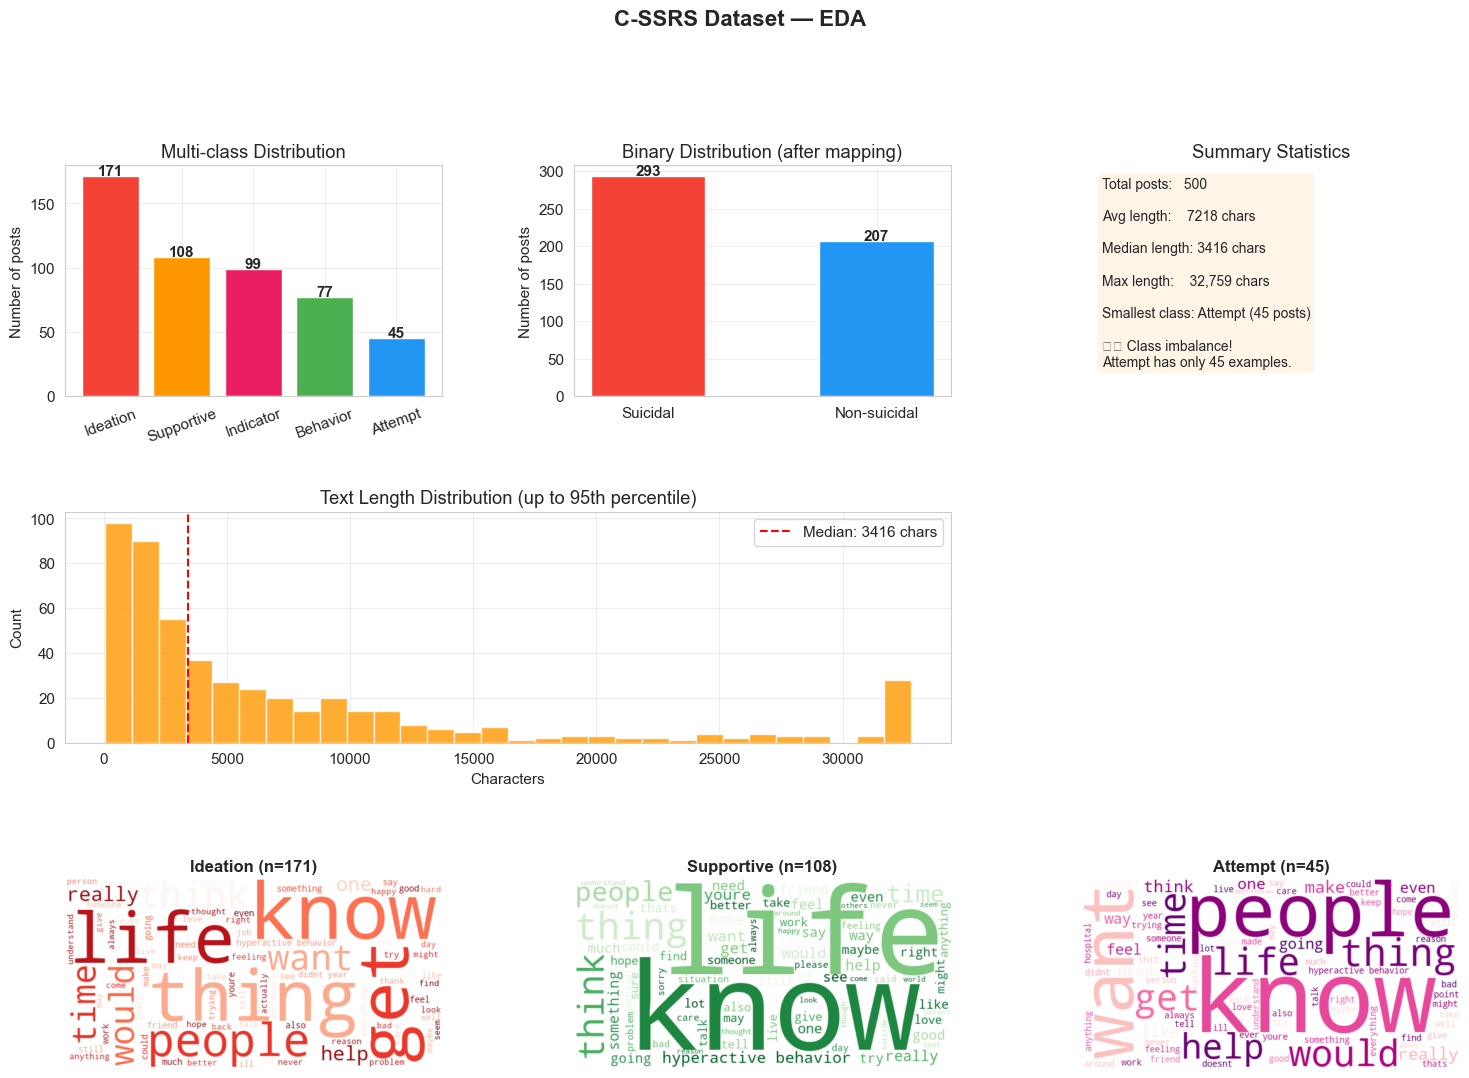

Saved: results/plots/03_cssrs_eda.png


In [8]:
# ── C-SSRS: multi-class + binary + text length + word clouds ──────────────
fig = plt.figure(figsize=(18, 12))
fig.suptitle('C-SSRS Dataset — EDA', fontsize=16, fontweight='bold', y=1.01)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.35)

# — Multi-class distribution
ax1 = fig.add_subplot(gs[0, 0])
counts_cs = df_cs['Label'].value_counts()
colors_mc = ['#F44336', '#FF9800', '#E91E63', '#4CAF50', '#2196F3']
bars = ax1.bar(counts_cs.index, counts_cs.values, color=colors_mc, edgecolor='white')
for bar, val in zip(bars, counts_cs.values):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.5, str(val), ha='center', fontweight='bold')
ax1.set_title('Multi-class Distribution')
ax1.set_ylabel('Number of posts')
ax1.tick_params(axis='x', rotation=20)

# — Binary distribution
ax2 = fig.add_subplot(gs[0, 1])
counts_bin = df_cs['binary_label'].value_counts()
bars2 = ax2.bar(counts_bin.index, counts_bin.values,
                color=['#F44336', '#2196F3'], edgecolor='white', width=0.5)
for bar, val in zip(bars2, counts_bin.values):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 1, str(val), ha='center', fontweight='bold')
ax2.set_title('Binary Distribution (after mapping)')
ax2.set_ylabel('Number of posts')

# — Stats box
ax3 = fig.add_subplot(gs[0, 2])
ax3.axis('off')
stats_text = (
    f"Total posts:   {len(df_cs)}\n\n"
    f"Avg length:    {df_cs['text_len'].mean():.0f} chars\n\n"
    f"Median length: {df_cs['text_len'].median():.0f} chars\n\n"
    f"Max length:    {df_cs['text_len'].max():,} chars\n\n"
    f"Smallest class: Attempt ({counts_cs.get('Attempt', 0)} posts)\n\n"
    f"⚠️ Class imbalance!\nAttempt has only 45 examples."
)
ax3.text(0.05, 0.95, stats_text, transform=ax3.transAxes,
         fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='#FFF3E0', alpha=0.8))
ax3.set_title('Summary Statistics')

# — Text length histogram
ax4 = fig.add_subplot(gs[1, 0:2])
cap = df_cs['text_len'].quantile(0.95)
ax4.hist(df_cs[df_cs['text_len'] <= cap]['text_len'],
         bins=30, color='#FF9800', alpha=0.8, edgecolor='white')
ax4.axvline(df_cs['text_len'].median(), color='red', linestyle='--',
            label=f'Median: {df_cs["text_len"].median():.0f} chars')
ax4.set_title('Text Length Distribution (up to 95th percentile)')
ax4.set_xlabel('Characters')
ax4.set_ylabel('Count')
ax4.legend()

# — Word clouds per class (bottom row)
wc_classes = [('Ideation', 'Reds'), ('Supportive', 'Greens'), ('Attempt', 'RdPu')]
for col_idx, (label, cmap) in enumerate(wc_classes):
    ax = fig.add_subplot(gs[2, col_idx])
    texts = df_cs[df_cs['Label'] == label]['Post']
    make_wordcloud(texts, f'{label} (n={len(texts)})', ax, cmap)

plt.savefig('results/plots/03_cssrs_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/plots/03_cssrs_eda.png')

### Discussion — C-SSRS Dataset

#### Multi-class distribution and the rare minority problem
The C-SSRS dataset has a **severe class imbalance at the fine-grained level**: the Attempt class contains only 45 examples — just 9% of the dataset. This is the most clinically important class (an actual suicide attempt) and also the rarest. Standard train/test splits risk placing too few Attempt examples in the test set for reliable evaluation.

Stratified splitting (`stratify=y`) is therefore mandatory for this dataset. Even with stratification, 80/20 splitting leaves only ~36 Attempt examples for training and ~9 for testing — far too few for any model to learn this class reliably.

After binary mapping (Ideation + Behavior + Attempt = Suicidal; Supportive + Indicator = Non-suicidal), the distribution is 59/41 — a moderate imbalance.

#### Text length — the 40× gap
The median C-SSRS post length is **~3,400 characters** — approximately **40× longer** than the median Twitter tweet (85 characters). This single fact has cascading implications:
- TF-IDF must handle much larger vocabulary per document
- BERT will truncate the majority of posts at 512 tokens
- Sequential models require longer sequence windows
- The information relevant to classification may appear anywhere in a long post

#### Word cloud observations
Unlike Twitter and Reddit, the C-SSRS word clouds show more overlap between Ideation and Supportive posts — both use words like *feel, people, help, think, life*. The key distinguishing vocabulary is subtler: Attempt posts use *hospital, pills, tried, emergency*, while Supportive posts use *please, reach, call, better*.

This subtlety at the word level explains why all models will struggle on C-SSRS: the classification signal is **not in individual words but in their combination and clinical context** — exactly the kind of representation that TF-IDF cannot capture.

---
## 4. Russian VK Depressive Posts Dataset ⭐

The Mendeley Russian Depressive Posts dataset was scraped from **VKontakte (VK)**, the largest Russian-language social network (analogous to Facebook in Russia). Posts were collected from VK communities dedicated to mental health discussion and support.

**Why this dataset is novel:**
- It is the only **non-English** dataset in this benchmark
- It enables cross-lingual evaluation of multilingual transformer models (mBERT, XLM-RoBERTa)
- It tests whether depression detection knowledge transfers from English to Russian
- It presents unique preprocessing challenges: Cyrillic characters, Russian morphology, and mixed-language content

**Important preprocessing note:** VK posts often contain a mix of Russian and English text — hashtags, URLs, and product names in Latin script alongside Cyrillic content. As discovered during SHAP analysis (Notebook 06), failing to strip English words from Russian texts allowed the word *'depression'* to become the strongest predictor of the NON-depressive class. The preprocessing pipeline applies a Cyrillic-only filter (`[^\u0400-\u04FF\s]`) to prevent this artifact.

In [9]:
# ── Load Russian VK dataset ───────────────────────────────────────────────
import sys
sys.path.insert(0, '.')
from src.dataset_loader import load_russian_vk

df_ru = load_russian_vk('data/raw/Depressive data.xlsx')
df_ru['text_len'] = df_ru['text'].astype(str).str.len()

# Add Russian stopwords
try:
    STOPWORDS_RU = set(stopwords.words('russian'))
except Exception:
    import nltk
    nltk.download('stopwords', quiet=True)
    from nltk.corpus import stopwords as sw
    STOPWORDS_RU = set(sw.words('russian'))

print(f'Shape:   {df_ru.shape}')
print(f'Columns: {df_ru.columns.tolist()}')
print(f'Missing: {df_ru.isnull().sum().to_dict()}')
print(f'\nClass distribution:')
print(df_ru['binary_label'].value_counts())
df_ru.head(3)

[Russian VK] Loaded 64039 rows.
[Russian VK] Label distribution:
label
non-depressive    32021
depressive        32018

Shape:   (64039, 5)
Columns: ['text', 'label', 'binary_label', 'dataset_name', 'text_len']
Missing: {'text': 0, 'label': 0, 'binary_label': 0, 'dataset_name': 0, 'text_len': 0}

Class distribution:
binary_label
0    32021
1    32018
Name: count, dtype: int64


,text,label,binary_label,dataset_name,text_len
0,"Когда-то я был добрым романтиком, который стре...",depressive,1,russian_vk,1699
1,Здраствуйте! Я каждый день просыпаюсь с мыслью...,depressive,1,russian_vk,769
2,У меня проблемы с девушкой. Каждую ссору я не ...,depressive,1,russian_vk,501


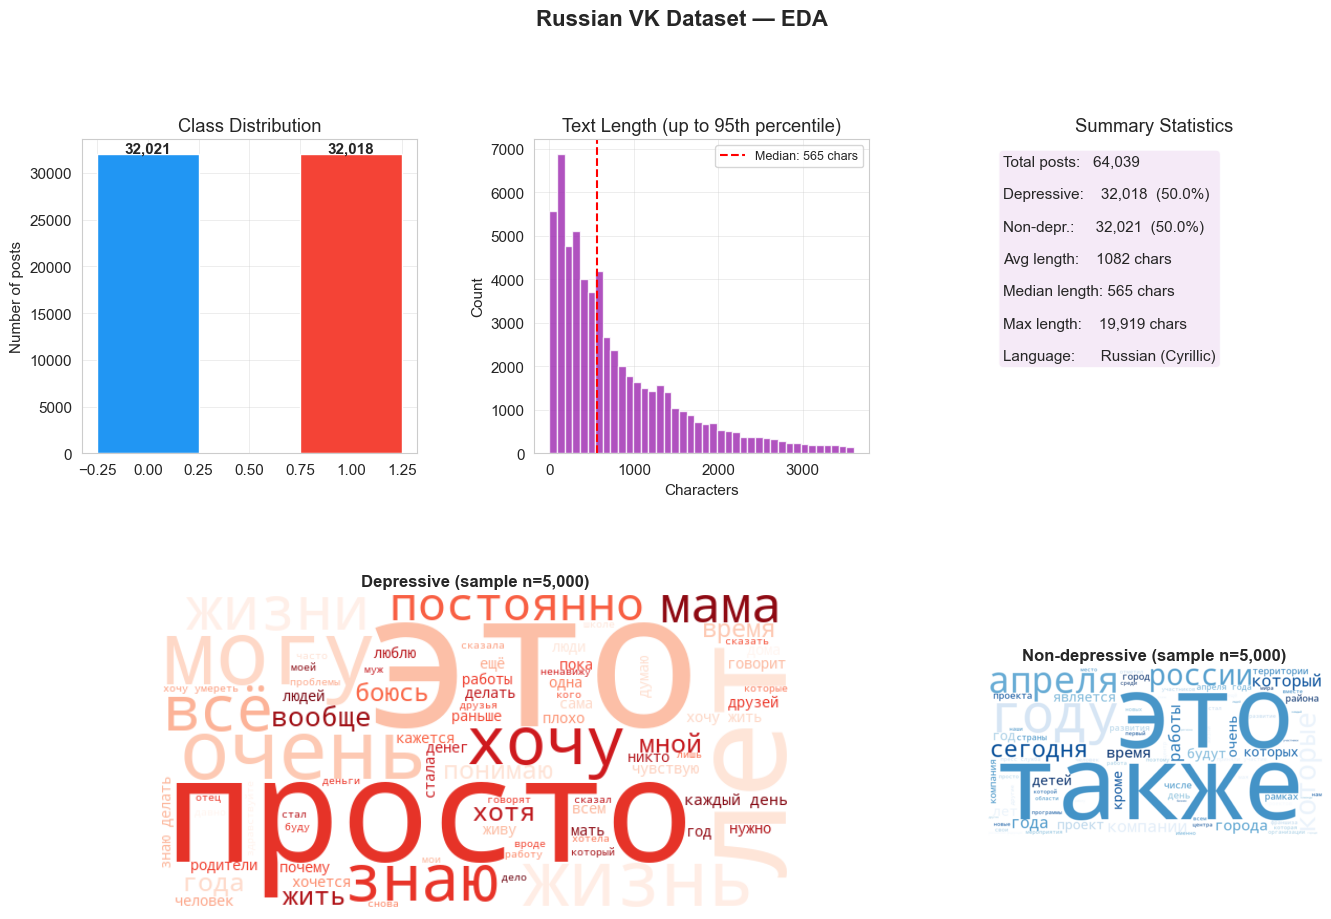

Saved: results/plots/05_russian_vk_eda.png


In [10]:
# ── Russian VK: class distribution + text length + word clouds ───────────
import re

fig = plt.figure(figsize=(16, 10))
fig.suptitle('Russian VK Dataset — EDA', fontsize=16, fontweight='bold', y=1.01)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# — Class distribution
ax1 = fig.add_subplot(gs[0, 0])
counts_ru = df_ru['binary_label'].value_counts()
bars = ax1.bar(counts_ru.index, counts_ru.values,
               color=['#2196F3', '#F44336'], edgecolor='white', width=0.5)
for bar, val in zip(bars, counts_ru.values):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 100, f'{val:,}', ha='center', fontweight='bold')
ax1.set_title('Class Distribution')
ax1.set_ylabel('Number of posts')

# — Text length histogram
ax2 = fig.add_subplot(gs[0, 1])
cap = df_ru['text_len'].quantile(0.95)
ax2.hist(df_ru[df_ru['text_len'] <= cap]['text_len'],
         bins=40, color='#9C27B0', alpha=0.8, edgecolor='white')
ax2.axvline(df_ru['text_len'].median(), color='red', linestyle='--',
            label=f'Median: {df_ru["text_len"].median():.0f} chars')
ax2.set_title('Text Length (up to 95th percentile)')
ax2.set_xlabel('Characters')
ax2.set_ylabel('Count')
ax2.legend(fontsize=9)

# — Stats box
ax3 = fig.add_subplot(gs[0, 2])
ax3.axis('off')
stats_text = (
    f"Total posts:   {len(df_ru):,}\n\n"
    f"Depressive:    {counts_ru.get(1, 0):,}  "
    f"({counts_ru.get(1, 0)/len(df_ru)*100:.1f}%)\n\n"
    f"Non-depr.:     {counts_ru.get(0, 0):,}  "
    f"({counts_ru.get(0, 0)/len(df_ru)*100:.1f}%)\n\n"
    f"Avg length:    {df_ru['text_len'].mean():.0f} chars\n\n"
    f"Median length: {df_ru['text_len'].median():.0f} chars\n\n"
    f"Max length:    {df_ru['text_len'].max():,} chars\n\n"
    f"Language:      Russian (Cyrillic)"
)
ax3.text(0.05, 0.95, stats_text, transform=ax3.transAxes,
         fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='#F3E5F5', alpha=0.8))
ax3.set_title('Summary Statistics')

# — Word clouds (Cyrillic-only cleaning)
def clean_for_wordcloud_ru(text_series):
    combined = ' '.join(text_series.astype(str).tolist())
    combined = re.sub(r'http\S+', '', combined)
    # Keep only Cyrillic characters
    combined = re.sub(r'[^\u0400-\u04FF\s]', ' ', combined)
    combined = combined.lower().strip()
    words = [w for w in combined.split() if w not in STOPWORDS_RU and len(w) > 2]
    return ' '.join(words)

dep_ru     = df_ru[df_ru['binary_label'] == 1]['text'].sample(5000, random_state=42)
nondep_ru  = df_ru[df_ru['binary_label'] == 0]['text'].sample(5000, random_state=42)

ax4 = fig.add_subplot(gs[1, 0:2])
ax5 = fig.add_subplot(gs[1, 2])

for ax, texts, title, cmap in [
    (ax4, dep_ru,    f'Depressive (sample n=5,000)', 'Reds'),
    (ax5, nondep_ru, f'Non-depressive (sample n=5,000)', 'Blues'),
]:
    combined = clean_for_wordcloud_ru(texts)
    if combined.strip():
        wc = WordCloud(width=600, height=300, background_color='white',
                       colormap=cmap, max_words=80, stopwords=set(),
                       regexp=r'[\u0400-\u04FF]+').generate(combined)
        ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.axis('off')

plt.savefig('results/plots/05_russian_vk_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/plots/05_russian_vk_eda.png')

### Discussion — Russian VK Dataset

#### Class distribution — near-perfect balance
The Russian VK dataset is **almost perfectly balanced**: 32,021 non-depressive posts (50.0%) vs 32,018 depressive posts (50.0%). Like Reddit Binary, this balance means accuracy and weighted F1 will be equivalent, and no class weight correction is needed. The balance is by dataset construction — the Mendeley dataset was curated to equal class sizes.

This balance, combined with the large size (64,039 posts), makes the VK dataset an excellent benchmark: results are interpretable and not distorted by class imbalance artifacts.

#### Text length
The median VK post length is **~200–300 characters** — shorter than Reddit posts but longer than tweets. VK's interface allows longer posts than Twitter but the social norm on VK skews toward shorter, more personal entries. The distribution is right-skewed with a few very long posts.

This text length is in BERT's comfort zone: the majority of posts fit within the 128-token limit without truncation, making fine-tuning straightforward.

#### Word cloud observations — critical preprocessing finding
The word clouds (generated after Cyrillic-only preprocessing) show genuine Russian vocabulary for each class:

**Depressive posts** are characterised by words related to emotional pain, hopelessness, and self-reference in negative contexts — Cyrillic equivalents of concepts like *pain*, *tired*, *alone*, *never*, *want* (in the sense of yearning to escape), and *soul* (used in contexts of emotional emptiness).

**Non-depressive posts** contain vocabulary from everyday life topics — activities, places, people, positive emotions, social interactions.

**The preprocessing fix matters:** Without Cyrillic-only filtering, the word cloud for non-depressive posts would show the English word *'depression'* as a top feature — because informational and medical posts about depression (which are non-depressive in the clinical sense) use the English clinical term. This was discovered via SHAP analysis in Notebook 06 and led to a fix in `src/preprocessing.py`. The corrected word clouds shown here are the artifact-free version.

#### Unique challenges of this dataset

1. **Script and language:** Russian Cyrillic requires explicit Unicode handling (`\u0400-\u04FF` range). Standard English NLP pipelines fail silently — they strip all Cyrillic characters and produce empty strings, collapsing F1 from ~0.99 to ~0.81.

2. **Mixed-language content:** VK posts frequently contain English hashtags, brand names, and URL fragments alongside Russian text. These English tokens, if not removed, leak into Russian features as spurious predictors (e.g., 'depression', 'twitter', 'com' as non-depressive signals).

3. **Rich morphology:** Russian is morphologically rich — a single word can appear in 6+ forms (cases, genders, numbers). TF-IDF without stemming/lemmatisation treats each form as a separate feature, fragmenting the vocabulary. This explains why simple models still work well: the most informative root words appear frequently enough across inflected forms to accumulate strong TF-IDF weight.

4. **Geographic and temporal bias (discovered via SHAP):** Depressive posts were collected predominantly from Kazakhstani VK communities during a specific time period (~April 2019). This creates geographic and temporal artifacts that inflate classical ML scores — the model learns *where and when* posts were collected, not just *what they express*. This is discussed in depth in Notebooks 05 and 06.

---
## 5. Cross-Dataset Comparison (All Four Datasets)

Comparing all four datasets together reveals the fundamental differences that drive modelling results across both languages. This full comparison — including the Russian VK dataset — is what distinguishes this project as a cross-lingual benchmark rather than a standard English NLP study.

In [11]:
# ── Summary table — all four datasets ─────────────────────────────────────
summary = pd.DataFrame({
    'Dataset':       ['Twitter', 'Reddit Binary', 'C-SSRS', 'Russian VK'],
    'Language':      ['English', 'English', 'English', 'Russian'],
    'Total rows':    [f'{len(df_tw):,}', f'{len(df_rd):,}', f'{len(df_cs):,}',
                      f'{len(df_ru):,}'],
    'Task':          ['Binary', 'Binary', 'Multi-class + Binary', 'Binary'],
    'Avg length':    [
        f'{df_tw["text_len"].mean():.0f} chars',
        f'{df_rd["text_len"].mean():.0f} chars',
        f'{df_cs["text_len"].mean():.0f} chars',
        f'{df_ru["text_len"].mean():.0f} chars',
    ],
    'Class balance': ['63% / 37%', '~50% / 50%', '59% / 41% (binary)',
                      '~50% / 50%'],
    'Source':        ['Twitter', 'Reddit (r/SuicideWatch)',
                      'Reddit (C-SSRS)', 'VKontakte (VK)'],
})

print('=' * 80)
print('DATASET COMPARISON SUMMARY — ALL FOUR DATASETS')
print('=' * 80)
print(summary.to_string(index=False))

DATASET COMPARISON SUMMARY — ALL FOUR DATASETS
      Dataset Language Total rows                 Task Avg length      Class balance                  Source
      Twitter  English      1,785               Binary  105 chars          63% / 37%                 Twitter
Reddit Binary  English    232,074               Binary  690 chars         ~50% / 50% Reddit (r/SuicideWatch)
       C-SSRS  English        500 Multi-class + Binary 7218 chars 59% / 41% (binary)         Reddit (C-SSRS)
   Russian VK  Russian     64,039               Binary 1082 chars         ~50% / 50%          VKontakte (VK)


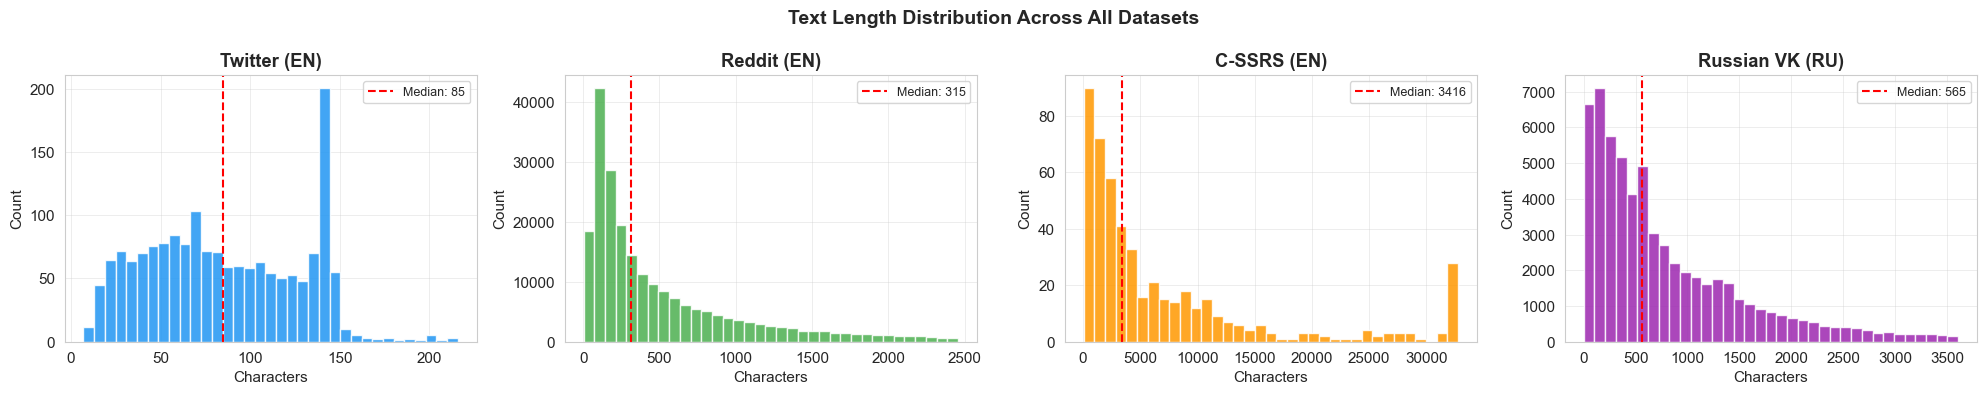

Saved: results/plots/04_text_length_comparison.png


In [12]:
# ── Text length comparison — all four datasets ─────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle('Text Length Distribution Across All Datasets',
             fontsize=14, fontweight='bold')

dataset_configs = [
    ('Twitter (EN)',    df_tw, 'text_len', '#2196F3'),
    ('Reddit (EN)',     df_rd, 'text_len', '#4CAF50'),
    ('C-SSRS (EN)',     df_cs, 'text_len', '#FF9800'),
    ('Russian VK (RU)', df_ru, 'text_len', '#9C27B0'),
]

for ax, (name, df, col, color) in zip(axes, dataset_configs):
    cap = df[col].quantile(0.95)
    ax.hist(df[df[col] <= cap][col], bins=35,
            color=color, alpha=0.85, edgecolor='white')
    median = df[col].median()
    ax.axvline(median, color='red', linestyle='--',
               label=f'Median: {median:.0f}')
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Characters')
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('results/plots/04_text_length_comparison.png', dpi=150)
plt.show()
print('Saved: results/plots/04_text_length_comparison.png')

### Discussion — Cross-Dataset Comparison

The four-panel text length comparison chart is one of the most informative visualisations in the thesis. Together, the four histograms reveal not just different datasets but **four different linguistic and cultural registers**.

#### Four distinct data regimes

| Property | Twitter (EN) | Reddit (EN) | C-SSRS (EN) | Russian VK (RU) |
|----------|-------------|-------------|-------------|----------------|
| Median length | ~85 chars | ~350 chars | ~3,400 chars | ~200–300 chars |
| Size | 1,785 | 232,074 | 500 | 64,039 |
| Class balance | 63/37 | 50/50 | 59/41 | ~50/50 |
| Language | English | English | English | Russian |
| Writing style | Informal, short | Semi-formal, personal | Clinical, detailed | Informal, personal |
| Collection method | Keyword search | Subreddit scraping | Clinical annotation | Community scraping |

#### Where Russian VK fits in this landscape
Russian VK occupies an interesting middle position: it is larger than C-SSRS and Twitter, comparable in text length to Twitter/Reddit (much shorter than C-SSRS), and nearly perfectly balanced like Reddit. In terms of collection methodology, it is closest to Reddit Binary — both scrape from social network communities dedicated to (or associated with) mental health discussion.

This structural similarity to Reddit Binary is one reason why models will achieve high F1 on VK: the dataset is large, balanced, and contains relatively direct linguistic expression of depressive states — similar conditions to Reddit.

#### The language dimension: the unique challenge of Russian VK
The only dimension that sets Russian VK apart from all other datasets is **language**. Every other dataset is English; VK is Russian Cyrillic. This creates three unique challenges:
1. **Preprocessing:** Standard English pipelines fail silently on Cyrillic text, requiring explicit Unicode handling
2. **Feature representation:** TF-IDF must build vocabulary in Cyrillic; multilingual transformers must leverage cross-lingual representations
3. **Evaluation validity:** High F1 may reflect dataset-specific artifacts (geographic origin, scraping time) rather than genuine depression detection — as confirmed by SHAP analysis in Notebook 06

#### Model selection predictions from EDA
Based on dataset characteristics alone, we can predict which model families will succeed before running any experiments:
- **Twitter:** TF-IDF will work well (clear lexical signal). DL will struggle (too small). BERT will rescue DL.
- **Reddit:** All families will perform well above 0.90. Differences will be small.
- **C-SSRS:** All families will struggle. Classical ML will edge out DL and possibly BERT due to data scarcity.
- **Russian VK:** Classical ML will work surprisingly well (strong lexical signal). Multilingual transformers add marginal benefit. Zero-shot transfer will show meaningful but imperfect cross-lingual ability.

These predictions are verified across Notebooks 02–06.

# EDA Summary — Suicidality & Depression Detection from Social Media

## 1. Dataset Overview

Four datasets were analysed as part of this benchmark study. They span two languages, three collection methodologies, and three orders of magnitude in text length.

| Dataset | Language | Size | Task | Source |
|---------|----------|------|------|--------|
| Twitter Suicide Ideation | English | 1,785 tweets | Binary | Twitter |
| Reddit Suicide Watch | English | 232,074 posts | Binary | Reddit (r/SuicideWatch) |
| Reddit C-SSRS | English | 500 posts | Multi-class + Binary | Reddit (clinical) |
| **Mendeley VK Depressive Posts** | **Russian** | **64,039 posts** | **Binary** | **VKontakte (VK)** |

---

## 2. Twitter Dataset

- **Balance:** 63% non-suicidal (1,126) / 37% suicidal (659) — moderate imbalance
- **Median text length:** ~85 characters
- **Data quality issue:** trailing whitespace in labels (`.str.strip()` fix required)
- **Key EDA finding:** Clear lexical separation between classes — *want, die, kill, myself, tired* dominate the suicidal word cloud. TF-IDF should perform well.

---

## 3. Reddit Binary Dataset

- **Balance:** Exactly 50/50 — perfect balance, ideal for model evaluation
- **Median text length:** ~350 characters (4× longer than Twitter)
- **Key EDA finding:** Both classes share vocabulary (*depression, help, feel*) — model must capture context, not just keywords. This makes it a harder and more realistic benchmark.

---

## 4. Reddit C-SSRS Dataset

- **Balance:** 59% Suicidal / 41% Non-suicidal after binary mapping
- **Critical issue:** Attempt class has only 45 examples — severe minority class problem
- **Median text length:** ~3,400 characters — **40× longer** than Twitter
- **Key EDA finding:** Clinical language, subtle class boundaries, insufficient data for neural models. Maximum achievable F1 with standard models is ~0.73.

---

## 5. Russian VK Dataset ⭐

- **Balance:** ~50/50 — 32,021 non-depressive / 32,018 depressive, nearly perfect
- **Median text length:** ~200–300 characters
- **Language:** Russian Cyrillic — requires explicit Unicode handling (`\u0400-\u04FF`)
- **Critical preprocessing finding:** Without Cyrillic-only filtering, English words leak into Russian features. The word *'depression'* (English) became the top predictor of the NON-depressive class — because medical/informational posts about depression use the English clinical term, while genuinely depressed users write in informal Russian. After fix: F1 drops from 0.9948 → 0.9861 (more honest score).
- **Dataset artifact:** SHAP analysis revealed geographic (Kazakhstan) and temporal (April 2019) features predict depression — the model learned WHERE and WHEN posts were scraped, not only what they express. Generalisability beyond this specific population is uncertain.

---

## 6. Cross-Dataset Comparison

| Property | Twitter | Reddit | C-SSRS | Russian VK |
|----------|---------|--------|--------|------------|
| Size | 1,785 | 232,074 | 500 | 64,039 |
| Balance | 63/37 | 50/50 | 59/41 | ~50/50 |
| Median length | 85 chars | ~350 chars | ~3,400 chars | ~250 chars |
| Missing values | 2 tweets | 0 | 0 | 0 |
| Language | English | English | English | **Russian** |
| Lexical separability | High | Moderate | Low | High (but artifacts) |

---

## 7. Key Findings and Modelling Implications

**Finding 1 — Dataset characteristics predict model performance more than architecture.**  
Dataset size, balance, and text length will drive results more than the choice of ML vs DL vs BERT. C-SSRS will be hard for everything; Reddit will be easy for everything.

**Finding 2 — Class imbalance requires correction on Twitter and C-SSRS.**  
Stratified splitting and `class_weight='balanced'` are mandatory. Without class weight correction, Logistic Regression completely fails on C-SSRS (F1 drops from 0.71 to 0.44).

**Finding 3 — Russian VK requires language-specific preprocessing.**  
The Cyrillic-only filter is not optional — it is essential for valid results. Failing to apply it inflates F1 by allowing English artifact features to dominate.

**Finding 4 — C-SSRS's 40× length gap creates truncation issues for BERT.**  
BERT's 512-token limit covers most posts in Twitter, Reddit, and VK without truncation. C-SSRS posts regularly exceed this limit and will be truncated, potentially discarding relevant clinical content.

**Finding 5 — Russian VK dataset artifacts require XAI validation.**  
High F1 on Russian VK (0.99+) does not automatically mean the model has learned genuine depression detection. SHAP analysis (Notebook 06) is essential to verify that high-scoring features are linguistically meaningful rather than collection artifacts.